In [1]:
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
urllib.request.urlretrieve(
    "https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/Global/Land_and_Ocean_complete.txt",
    "Land_and_Ocean_complete.txt"
)
data = np.loadtxt("Land_and_Ocean_complete.txt", comments="%", max_rows=2100)
print(data)

[[ 1.850e+03  1.000e+00 -7.530e-01 ...        nan        nan        nan]
 [ 1.850e+03  2.000e+00 -2.020e-01 ...        nan        nan        nan]
 [ 1.850e+03  3.000e+00 -3.670e-01 ...        nan        nan        nan]
 ...
 [ 2.024e+03  1.000e+01  1.368e+00 ...        nan        nan        nan]
 [ 2.024e+03  1.100e+01  1.313e+00 ...        nan        nan        nan]
 [ 2.024e+03  1.200e+01  1.289e+00 ...        nan        nan        nan]]


/tmp/ipykernel_13784/668581592.py:5: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=2100`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  data = np.loadtxt("Land_and_Ocean_complete.txt", comments="%", max_rows=2100)


In [3]:
print(data.shape)

(2100, 12)


In [4]:
columns = [
    "year", "month",
    "monthly_anomaly", "monthly_unc",
    "annual_anomaly", "annual_unc",
    "five_year_anomaly", "five_year_unc",
    "ten_year_anomaly", "ten_year_unc",
    "twenty_year_anomaly", "twenty_year_unc",
]

df = pd.DataFrame(data, columns=columns)

dtype_map = {
    "year": "int",
    "month": "int",
    "monthly_anomaly": "float",
    "monthly_unc": "float",
    "annual_anomaly": "float",
    "annual_unc": "float",
    "five_year_anomaly": "float",
    "five_year_unc": "float",
    "ten_year_anomaly": "float",
    "ten_year_unc": "float",
    "twenty_year_anomaly": "float",
    "twenty_year_unc": "float",
}
df = df.astype(dtype_map)

df["date"] = pd.to_datetime(
    {"year": df["year"], "month": df["month"], "day": 1}
)

print(df[:-5])

      year  month  monthly_anomaly  monthly_unc  annual_anomaly  annual_unc  \
0     1850      1           -0.753        0.365             NaN         NaN   
1     1850      2           -0.202        0.416             NaN         NaN   
2     1850      3           -0.367        0.373             NaN         NaN   
3     1850      4           -0.596        0.324             NaN         NaN   
4     1850      5           -0.619        0.267             NaN         NaN   
...    ...    ...              ...          ...             ...         ...   
2090  2024      3            1.343        0.043           1.331       0.031   
2091  2024      4            1.352        0.045           1.329       0.031   
2092  2024      5            1.223        0.035           1.322       0.032   
2093  2024      6            1.230        0.046           1.311       0.032   
2094  2024      7            1.229        0.047             NaN         NaN   

      five_year_anomaly  five_year_unc  ten_year_an

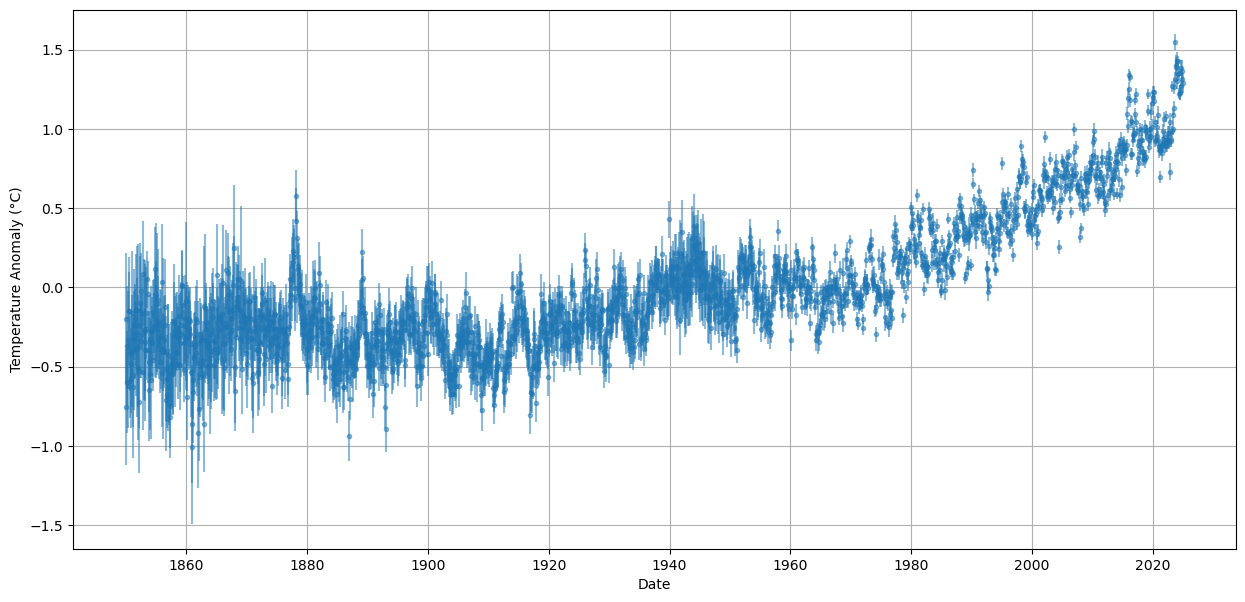

In [5]:
plt.figure(figsize=(15, 7))
plt.errorbar(df["date"], df["monthly_anomaly"], yerr=df["monthly_unc"], fmt="o", markersize=3, label="Monthly Anomaly", alpha=0.5)
plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()

plt.show()

In [6]:
urllib.request.urlretrieve(
    "https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/Global/Land_and_Ocean_summary.txt",
    "Land_and_Ocean_complete_annual.txt"
)
data_annual = np.loadtxt("Land_and_Ocean_complete_annual.txt", comments="%")
print(data_annual)

[[ 1.850e+03 -4.360e-01  1.700e-01 ...  1.560e-01        nan        nan]
 [ 1.851e+03 -3.210e-01  2.590e-01 ...  2.250e-01        nan        nan]
 [ 1.852e+03 -2.920e-01  2.490e-01 ...  2.170e-01 -3.160e-01  1.530e-01]
 ...
 [ 2.022e+03  9.360e-01  3.100e-02 ...  2.800e-02  9.580e-01  2.200e-02]
 [ 2.023e+03  1.229e+00  3.100e-02 ...  2.800e-02        nan        nan]
 [ 2.024e+03  1.311e+00  3.200e-02 ...  2.700e-02        nan        nan]]


In [7]:
columns = [
    "year",
    "annual_anomaly_above", "annual_unc_above",
    "five_year_anomaly_above", "five_year_unc_above",
    "annual_anomaly_below", "annual_unc_below",
    "five_year_anomaly_below", "five_year_unc_below",
]

df_annual = pd.DataFrame(data_annual, columns=columns)

dtype_map = {
    "year": "int",
    "annual_anomaly_above": "float",
    "annual_unc_above": "float",
    "five_year_anomaly_above": "float",
    "five_year_unc_above": "float",
    "annual_anomaly_below": "float",
    "annual_unc_below": "float",
    "five_year_anomaly_below": "float",
    "five_year_unc_below": "float",
}
df_annual = df_annual.astype(dtype_map)


print(df_annual[:-5])

     year  annual_anomaly_above  annual_unc_above  five_year_anomaly_above  \
0    1850                -0.436             0.170                      NaN   
1    1851                -0.321             0.259                      NaN   
2    1852                -0.292             0.249                   -0.325   
3    1853                -0.295             0.196                   -0.294   
4    1854                -0.283             0.130                   -0.309   
..    ...                   ...               ...                      ...   
165  2015                 0.923             0.027                    0.885   
166  2016                 1.059             0.027                    0.922   
167  2017                 0.962             0.026                    0.971   
168  2018                 0.888             0.028                    0.996   
169  2019                 1.024             0.031                    0.964   

     five_year_unc_above  annual_anomaly_below  annual_unc_belo

In [76]:
yerr_annual_above = df_annual["annual_unc_above"] / 2.
yerr_annual_below = df_annual["annual_unc_below"] / 2.

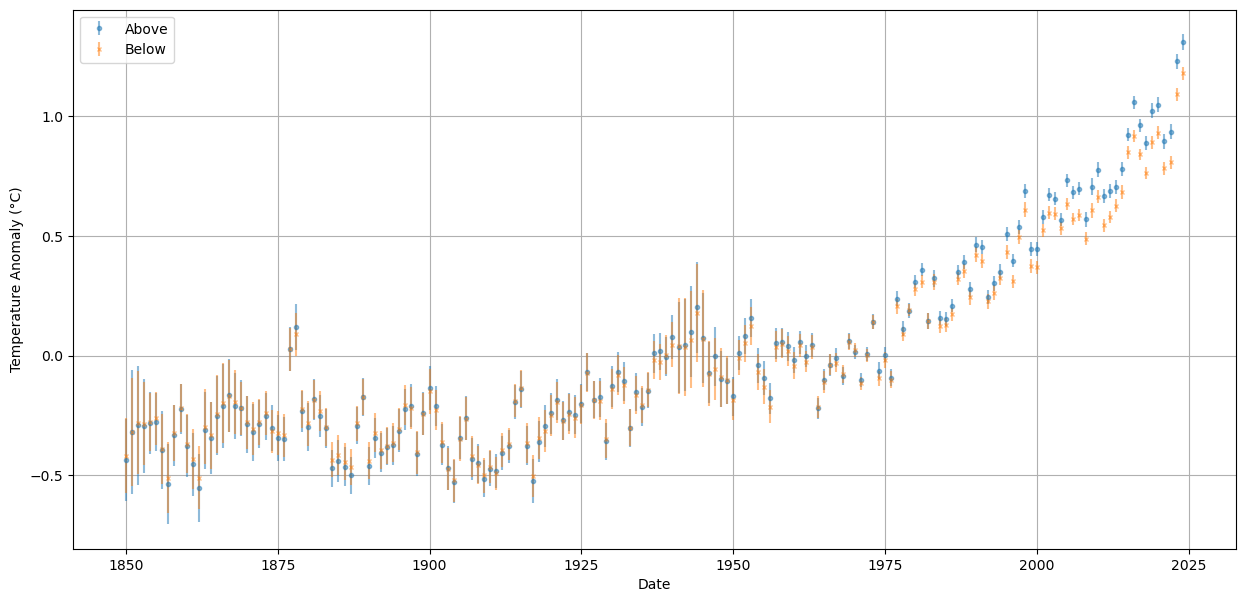

In [77]:
plt.figure(figsize=(15, 7))
plt.errorbar(df_annual["year"], df_annual["annual_anomaly_above"], yerr=df_annual["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)
plt.errorbar(df_annual["year"], df_annual["annual_anomaly_below"], yerr=df_annual["annual_unc_below"], fmt="x", markersize=3, label="Below", alpha=0.5)
plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()

In [78]:
import ultranest

In [79]:
# convert to np arrays for easier ingestion for ultranest
date = df_annual["year"].values
temp_anomaly = df_annual["annual_anomaly_above"].values


In [80]:
def constant_model(q):
    return q 

def constant_prior(cube):
    params = cube.copy()

    lower_bound = -10.0
    upper_bound = 10.0

    params[0] = lower_bound + cube[0] * (upper_bound - lower_bound)

    return params

def log_likelihood(params):
    q = params[0]
    model = constant_model(q)
    log_likelihood_value = -0.5 * ((temp_anomaly - model) ** 2 / yerr_annual_above ** 2).sum()

    return log_likelihood_value

parameters = ["q"]

In [81]:
sampler = ultranest.ReactiveNestedSampler(
    parameters, log_likelihood, constant_prior
)
result = sampler.run()
print(result)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-3e+04  -29145.77 [-29145.7707..-29145.7707]*| it/evals=4640/5200 eff=96.6667% N=400 0 0 0  
[ultranest] Likelihood function evaluations: 5226
[ultranest]   logZ = -2.915e+04 +- 0.1022
[ultranest] Effective samples strategy satisfied (ESS = 1274.4, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.11, need <0.5)
[ultranest]   logZ error budget: single: 0.14 bs:0.10 tail:0.03 total:0.11 required:<0.50
[ultranest] done iterating.
{'niter': 5065, 'logz': np.float64(-29154.07592655516), 'logzerr': np.float64(0.1803073880970662), 'logz_bs': np.float64(-29154.10675168337), 'logz_single': np.float64(-29154.07592655516), 'logzerr_tail': np.float64(0.034262365978065645), 'logzerr_bs': np.float64(0.17702215816098033), 'ess': np.float64(1274.362543775069), 'H': np.float64(7.803017740818177), 'Herr': np.float64(0.09584130536826156), 'posterior': {'mean'

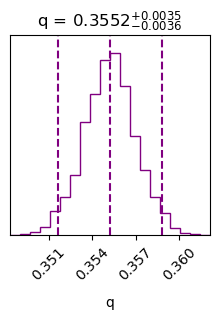

In [82]:
from ultranest.plot import cornerplot
cornerplot(
    result,
    title_fmt=".4f",
    quantiles=[0.025, 0.5, 0.975]
)
plt.show()

In [83]:
print(result["posterior"])

{'mean': [0.3552248767174048], 'stdev': [0.0017867300979793818], 'median': [0.35522943885641034], 'errlo': [0.3534507145731407], 'errup': [0.3569680841278515], 'information_gain_bits': [4.14647919764959]}


In [84]:
print(result["samples"])

[[0.35263399]
 [0.35619384]
 [0.35347528]
 ...
 [0.35367133]
 [0.35707287]
 [0.35968128]]


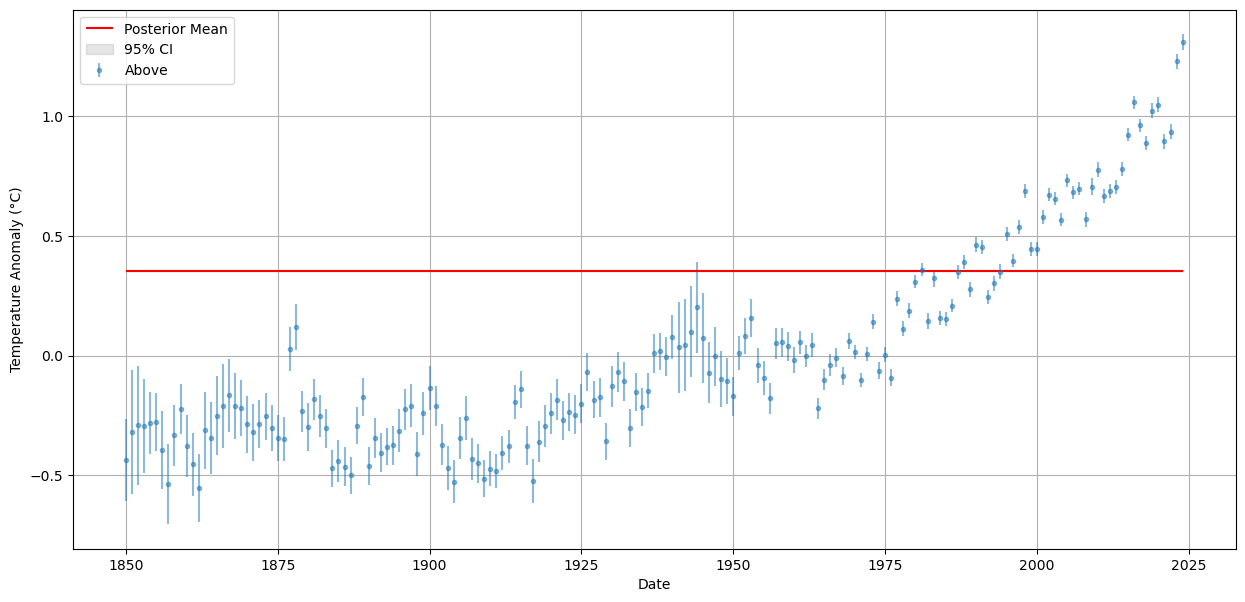

In [85]:
plt.figure(figsize=(15, 7))
plt.errorbar(df_annual["year"], df_annual["annual_anomaly_above"], yerr=df_annual["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)
plt.hlines(result["posterior"]["mean"], df_annual["year"].min(), df_annual["year"].max(), color="red", label="Posterior Mean")
q_samples = result["samples"][:, 0]
ci_low, ci_high = np.percentile(q_samples, [2.5, 97.5])

plt.fill_between(
    [df_annual["year"].min(), df_annual["year"].max()],
    ci_low,
    ci_high,
    color="gray",
    alpha=0.2,
    label="95% CI",
)
plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()

In [86]:
def linear_model(x, q, m):
    return q + m*x

def linear_prior(cube):
    params = cube.copy()

    lo_0 = -2000.0
    hi_0 = 2000.0
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)

    lo_1 = -5.
    hi_1 = 5.
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)

    return params

def log_linear_likelihood(params):
    q = params[0]
    m = params[1]
    model = linear_model(date, q, m)
    log_likelihood_value = -0.5 * ((temp_anomaly - model) ** 2 / yerr_annual_above ** 2).sum()

    return log_likelihood_value

parameters_linear = ["q", "m"]

In [87]:
sampler_linear = ultranest.ReactiveNestedSampler(
    parameters_linear, log_linear_likelihood, linear_prior
)
result_linear = sampler_linear.run()
print(result_linear)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-7e+03  915.43 [-6915.4393..-6915.4393]*| it/evals=11720/15968 eff=75.2826% N=400   0   0    0   
[ultranest] Likelihood function evaluations: 15976
[ultranest]   logZ = -6940 +- 0.158
[ultranest] Effective samples strategy satisfied (ESS = 1615.3, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.16, need <0.5)
[ultranest]   logZ error budget: single: 0.24 bs:0.16 tail:0.01 total:0.16 required:<0.50
[ultranest] done iterating.
{'niter': 12128, 'logz': np.float64(-6940.148684897075), 'logzerr': np.float64(0.21503105150343066), 'logz_bs': np.float64(-6940.216481839818), 'logz_single': np.float64(-6940.148684897075), 'logzerr_tail': np.float64(0.009947056696546497), 'logzerr_bs': np.float64(0.21480085934126691), 'ess': np.float64(1615.316651993042), 'H': np.float64(23.700198385476142), 'Herr': np.float64(0.14779536498551538), 'posterior': {'me

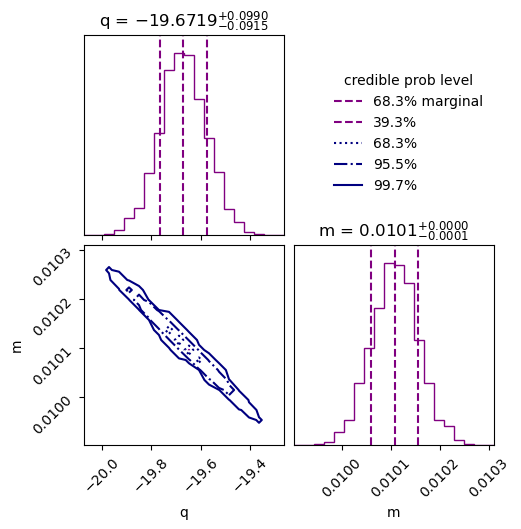

In [88]:
cornerplot(
    result_linear,
    title_fmt=".4f",
    #quantiles=[0.025, 0.5, 0.975]
)
plt.show()

In [89]:
print(result_linear["posterior"])
print(result_linear["samples"])

{'mean': [-19.670756134551016, 0.010108355040781362], 'stdev': [0.0951526319299735, 4.800435455677408e-05], 'median': [-19.6725200788062, 0.010109228826720162], 'errlo': [-19.763418129231695, 0.01005904739352026], 'errup': [-19.57293856347269, 0.01015460652660849], 'information_gain_bits': [4.14647919764959, 4.14647919764959]}
[[-1.98068261e+01  1.01772001e-02]
 [-1.97423855e+01  1.01459851e-02]
 [-1.96479442e+01  1.00954360e-02]
 ...
 [-1.95764922e+01  1.00622038e-02]
 [-1.95108585e+01  1.00266134e-02]
 [-1.96313346e+01  1.00882641e-02]]


In [90]:
from ultranest.plot import PredictionBand

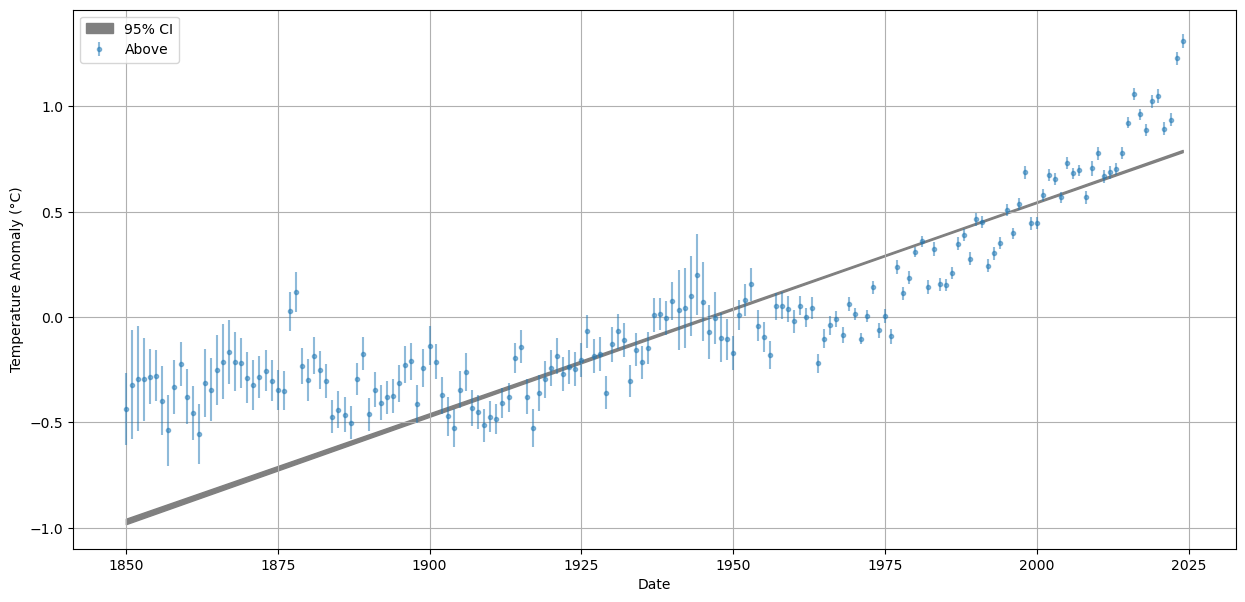

In [91]:
plt.figure(figsize=(15, 7))
plt.errorbar(df_annual["year"], df_annual["annual_anomaly_above"], yerr=df_annual["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df_annual["year"].min(), df_annual["year"].max(), 100)
band = PredictionBand(year_range)

for params in result_linear["samples"]:
    q, m = params
    band.add(linear_model(year_range, q, m))

#band.line(color="red")
band.shade(color="gray", label="95% CI", q=0.475)


plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()

In [104]:
def exponential_model(x, q, a, m):
    # Rescale time to avoid overflow in exp for calendar-year inputs.
    t = (x - 1950.0) / 50.0
    #exponent = np.clip(m * t, -50.0, 50.0)
    return q + a * np.exp(m * t)


def exponential_prior(cube):
    params = cube.copy()

    lo_0 = -2.0
    hi_0 = 2.0
    params[0] = lo_0 + cube[0] * (hi_0 - lo_0)

    lo_1 = -2.0
    hi_1 = 2.0
    params[1] = lo_1 + cube[1] * (hi_1 - lo_1)

    lo_2 = -4.0
    hi_2 = 4.0
    params[2] = lo_2 + cube[2] * (hi_2 - lo_2)

    return params


def log_exponential_likelihood(params):
    q, a, m = params
    model = exponential_model(date, q, a, m)

    if not np.all(np.isfinite(model)):
        return -1e300

    resid = temp_anomaly - model
    variance = np.asarray(yerr_annual_above) ** 2

    if np.any(variance <= 0) or not np.all(np.isfinite(variance)):
        return -1e300

    log_likelihood_value = -0.5 * np.sum((resid ** 2) / variance)

    if not np.isfinite(log_likelihood_value):
        return -1e300

    return log_likelihood_value


parameters_exponential = ["q", "a", "m"]

In [105]:
sampler_exponential = ultranest.ReactiveNestedSampler(
    parameters_exponential, log_exponential_likelihood, exponential_prior
)
result_exponential = sampler_exponential.run()
print(result_exponential)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-2e+03  821.80 [-1821.8655..-1821.8654]*| it/evals=9600/50938 eff=18.9956% N=400 0  0  0 
[ultranest] Likelihood function evaluations: 50949
[ultranest]   logZ = -1841 +- 0.1561
[ultranest] Effective samples strategy satisfied (ESS = 1877.1, need >400)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <0.50 nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.16, need <0.5)
[ultranest]   logZ error budget: single: 0.21 bs:0.16 tail:0.01 total:0.16 required:<0.50
[ultranest] done iterating.
{'niter': 10009, 'logz': np.float64(-1841.2550065440446), 'logzerr': np.float64(0.37136022057855655), 'logz_bs': np.float64(-1841.2291935208348), 'logz_single': np.float64(-1841.2550065440446), 'logzerr_tail': np.float64(0.009946852956318253), 'logzerr_bs': np.float64(0.37122698385815056), 'ess': np.float64(1877.1481873251705), 'H': np.float64(17.92953860939997), 'Herr': np.float64(0.15449127170375293), 'posterior': {'mean':

In [108]:
df_results = pd.DataFrame(result_exponential["samples"], columns=parameters_exponential)
df_results.describe()

,q,a,m
count,10009.000000,10009.000000,10009.000000
mean,-0.411067,0.303615,1.113864
std,0.007721,0.006695,0.013165
min,-0.439403,0.279306,1.061613
25%,-0.416540,0.299205,1.105030
50%,-0.411094,0.303501,1.113803
75%,-0.405669,0.308098,1.122333
max,-0.383828,0.330428,1.162066


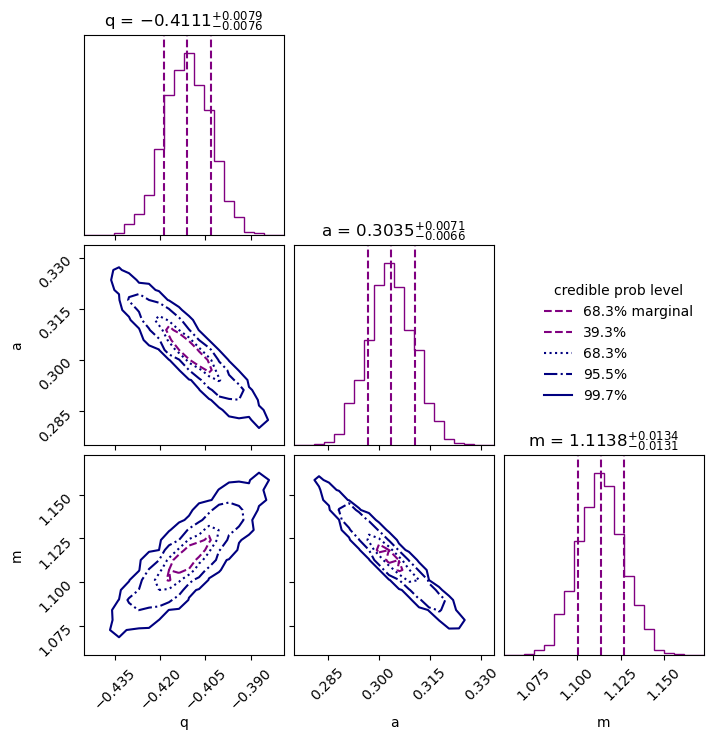

In [106]:
cornerplot(
    result_exponential,
    title_fmt=".4f",
    #quantiles=[0.025, 0.5, 0.975]
)
plt.show()

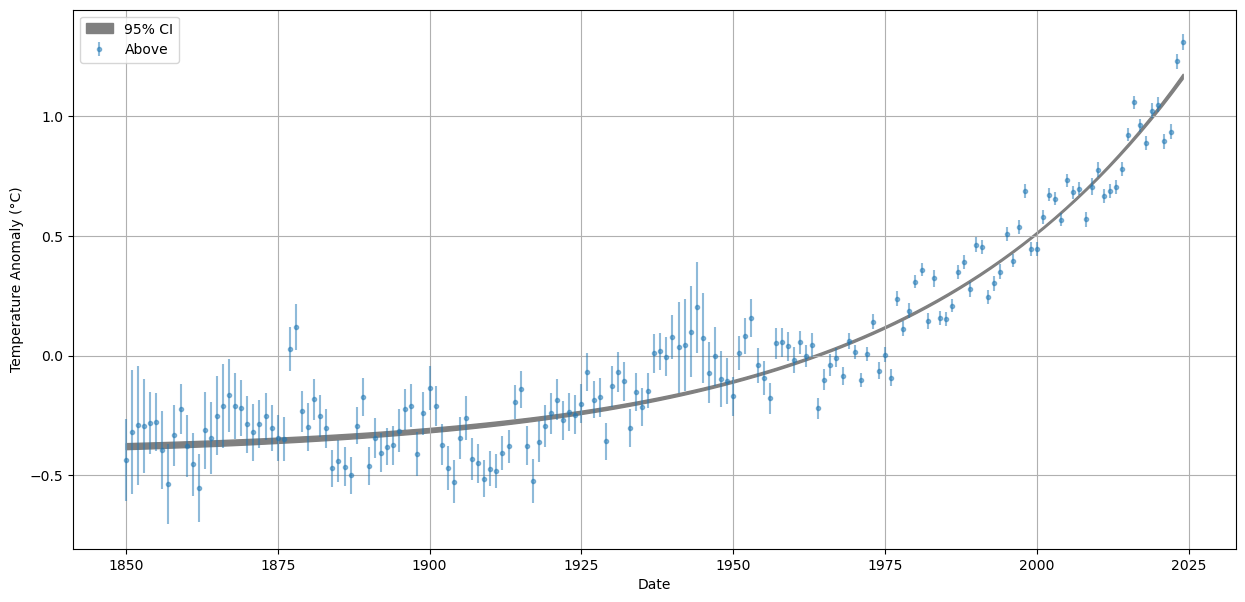

In [107]:
plt.figure(figsize=(15, 7))
plt.errorbar(df_annual["year"], df_annual["annual_anomaly_above"], yerr=df_annual["annual_unc_above"], fmt="o", markersize=3, label="Above", alpha=0.5)

year_range = np.linspace(df_annual["year"].min(), df_annual["year"].max(), 100)
band = PredictionBand(year_range)

for params in result_exponential["samples"]:
    q, a, m = params
    band.add(exponential_model(year_range, q, a, m))

#band.line(color="red")
band.shade(color="gray", label="95% CI", q=0.475)


plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.grid()
plt.legend()

plt.show()